# Sierraleone Solar EDA Notebook

## Imports

In [22]:
from pathlib import Path
import os
import warnings
warnings.simplefilter('ignore')

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 120
sns.set(style='whitegrid')

In [23]:
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"

COUNTRY = "Sierraleone"
INPUT_PATH = DATA_DIR / "sierraleone-bumbuna.csv"
OUTPUT_PATH = DATA_DIR / "sierraleone-bumbuna_clean.csv"
KEY_COLUMNS = ["GHI", "DNI", "DHI", "ModA", "ModB", "WS", "WSgust"]
TIMESTAMP_COL = "Timestamp"
CLEANING_FLAG_COL = "Cleaning"

# Helpers

In [24]:
def safe_read_csv(path, parse_dates=None):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Input file not found at: {path}")
    return pd.read_csv(path, parse_dates=parse_dates)

def zscore_flags(df, cols, thresh=3.0):
    flags = pd.DataFrame(index=df.index)
    for c in cols:
        if c in df.columns:
            col = pd.to_numeric(df[c], errors='coerce')
            z = (col - col.mean()) / (col.std(ddof=0) if col.std(ddof=0) != 0 else 1)
            flags[c + '_z'] = z.abs() > thresh
        else:
            flags[c + '_z'] = False
    return flags

def savefig_optional(fig, fname=None):
    if fname:
        fig.savefig(fname, bbox_inches='tight')

# Load data

In [25]:
try:
    # attempt to parse timestamp if present
    sample = pd.read_csv(INPUT_PATH, nrows=0)
    parse_dates = [TIMESTAMP_COL] if TIMESTAMP_COL in sample.columns else None
    df = safe_read_csv(INPUT_PATH, parse_dates=parse_dates)
    print(f"Loaded {len(df)} rows x {len(df.columns)} columns from {INPUT_PATH}")
except Exception as e:
    print(str(e))
    df = pd.DataFrame()

Loaded 525600 rows x 19 columns from c:\Users\Lenovo\Desktop\AI\Week0\solar-challenge-week0\data\sierraleone-bumbuna.csv


# 1 Summary Statistics & Missing-Value Report

In [26]:
if df.empty:
    print("No data loaded. Set COUNTRY and place CSV at data/benin_malanville.csv")
else:
    # show basic info
    display(df.head())
    print('--- dtypes ---')
    display(df.dtypes)

    print('--- df.describe() (numeric) ---')
    display(df.describe().T)

    print('--- Missing values per column ---')
    na_counts = df.isna().sum()
    na_pct = 100 * na_counts / len(df)
    missing_report = pd.DataFrame({'n_missing': na_counts, 'pct_missing': na_pct}).sort_values('pct_missing', ascending=False)
    display(missing_report)

    cols_over_5pct = missing_report[missing_report['pct_missing'] > 5].index.tolist()
    print(f"Columns with >5% missing: {cols_over_5pct}")

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-30 00:01:00,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.1,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
1,2021-10-30 00:02:00,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
2,2021-10-30 00:03:00,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
3,2021-10-30 00:04:00,-0.7,0.0,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.1,22.3,22.6,NaN
4,2021-10-30 00:05:00,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN


--- dtypes ---


Timestamp        datetime64[ns]
GHI                     float64
DNI                     float64
DHI                     float64
ModA                    float64
ModB                    float64
Tamb                    float64
RH                      float64
WS                      float64
WSgust                  float64
WSstdev                 float64
WD                      float64
WDstdev                 float64
BP                        int64
Cleaning                  int64
Precipitation           float64
TModA                   float64
TModB                   float64
Comments                float64
dtype: object

--- df.describe() (numeric) ---


,count,mean,min,25%,50%,75%,max,std
Timestamp,525600,2022-04-30 12:00:30.000000768,2021-10-30 00:01:00,2022-01-29 06:00:45,2022-04-30 12:00:30,2022-07-30 18:00:15,2022-10-30 00:00:00,NaN
GHI,525600.0,201.957515,-19.5,-2.8,0.3,362.4,1499.0,298.49515
DNI,525600.0,116.376337,-7.8,-0.3,-0.1,107.0,946.0,218.652659
DHI,525600.0,113.720571,-17.9,-3.8,-0.1,224.7,892.0,158.946032
ModA,525600.0,206.643095,0.0,0.0,3.6,359.5,1507.0,300.896893
ModB,525600.0,198.114691,0.0,0.0,3.4,345.4,1473.0,288.889073
Tamb,525600.0,26.319394,12.3,23.1,25.3,29.4,39.9,4.398605
RH,525600.0,79.448857,9.9,68.7,85.4,96.7,100.0,20.520775
WS,525600.0,1.146113,0.0,0.0,0.8,2.0,19.2,1.239248
WSgust,525600.0,1.691606,0.0,0.0,1.6,2.6,23.9,1.617053


--- Missing values per column ---


,n_missing,pct_missing
Comments,525600,100.0
GHI,0,0.0
Timestamp,0,0.0
DNI,0,0.0
DHI,0,0.0
ModB,0,0.0
ModA,0,0.0
RH,0,0.0
WS,0,0.0
WSgust,0,0.0


Columns with >5% missing: ['Comments']


# 2 Outlier Detection & Basic Cleaning

### Steps:
##### - Ensure numeric conversion for key columns
##### - Compute z-score flags for KEY_COLUMNS
##### - Create combined `is_outlier_any` flag
##### - Impute median for key columns where missing

In [27]:
if not df.empty:
    for c in KEY_COLUMNS:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

    zflags = zscore_flags(df, KEY_COLUMNS, thresh=3.0)
    df = pd.concat([df, zflags], axis=1)

    outlier_counts = {c: int(df[c + '_z'].sum()) for c in KEY_COLUMNS if c + '_z' in df.columns}
    print('Outlier counts (|Z|>3):', outlier_counts)

    z_col_names = [c + '_z' for c in KEY_COLUMNS if c + '_z' in df.columns]
    df['is_outlier_any'] = df[z_col_names].any(axis=1)
    print('Total rows flagged as outlier (any key col):', int(df['is_outlier_any'].sum()))

    # Impute medians for key columns
    medians = {}
    for c in KEY_COLUMNS:
        if c in df.columns:
            med = df[c].median()
            medians[c] = med
            n_missing_before = int(df[c].isna().sum())
            df[c].fillna(med, inplace=True)
            print(f"Imputed median for {c}: {med} (filled {n_missing_before} missing)")

    # Mark rows with impossible values (example: negative irradiance)
    for c in ['GHI','DNI','DHI']:
        if c in df.columns:
            neg_count = int((df[c] < 0).sum())
            if neg_count > 0:
                print(f"Warning: {neg_count} rows have negative values in {c} — setting to NaN then imputing median")
                df.loc[df[c] < 0, c] = np.nan
                df[c].fillna(medians.get(c, df[c].median()), inplace=True)

    cleaned = df.copy()
else:
    cleaned = df

Outlier counts (|Z|>3): {'GHI': 2477, 'DNI': 7586, 'DHI': 2986, 'ModA': 1604, 'ModB': 2041, 'WS': 3967, 'WSgust': 3665}
Total rows flagged as outlier (any key col): 16292
Imputed median for GHI: 0.3 (filled 0 missing)
Imputed median for DNI: -0.1 (filled 0 missing)
Imputed median for DHI: -0.1 (filled 0 missing)
Imputed median for ModA: 3.6 (filled 0 missing)
Imputed median for ModB: 3.4 (filled 0 missing)
Imputed median for WS: 0.8 (filled 0 missing)
Imputed median for WSgust: 1.6 (filled 0 missing)


# 3 Export cleaned DataFrame

In [28]:
if not cleaned.empty:
    os.makedirs('data', exist_ok=True)
    cleaned.to_csv(OUTPUT_PATH, index=False)
    print(f"✅ Cleaned data written to: {OUTPUT_PATH} ")

✅ Cleaned data written to: c:\Users\Lenovo\Desktop\AI\Week0\solar-challenge-week0\data\sierraleone-bumbuna_clean.csv 



# 4 Time Series Analysis
#### - Line charts of GHI, DNI, DHI, Tamb vs Timestamp
#### - Monthly & hourly aggregations to observe patterns

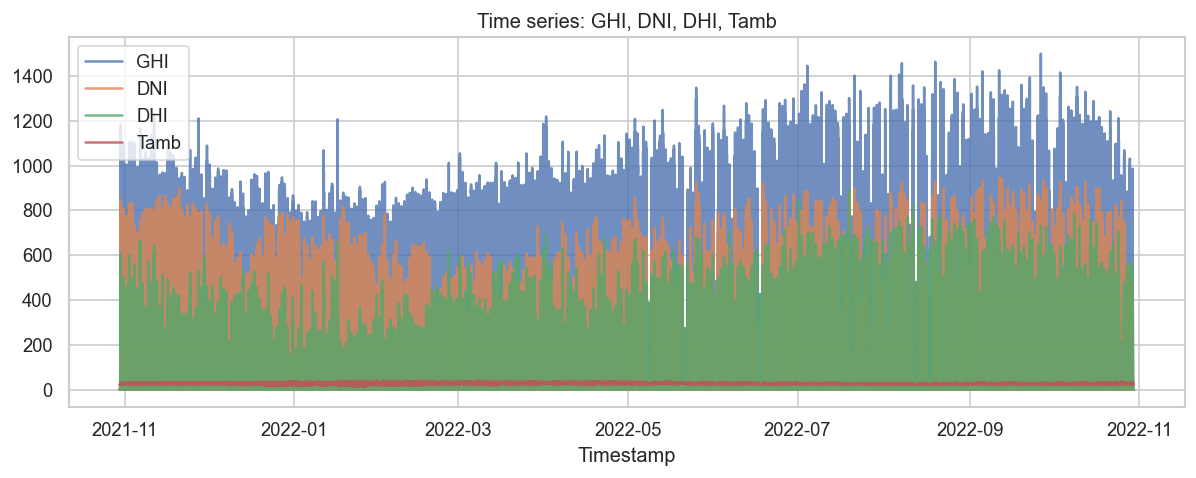

,GHI,DNI,DHI,Tamb
month,,,,
2021-10,225.457451,139.659569,116.553630,24.878638
2021-11,219.526903,173.479370,97.219398,26.488898
2021-12,199.455697,153.720500,93.867448,25.878651
2022-01,202.838831,168.922686,84.041116,25.329689
2022-02,225.520893,147.347307,113.424643,27.185801


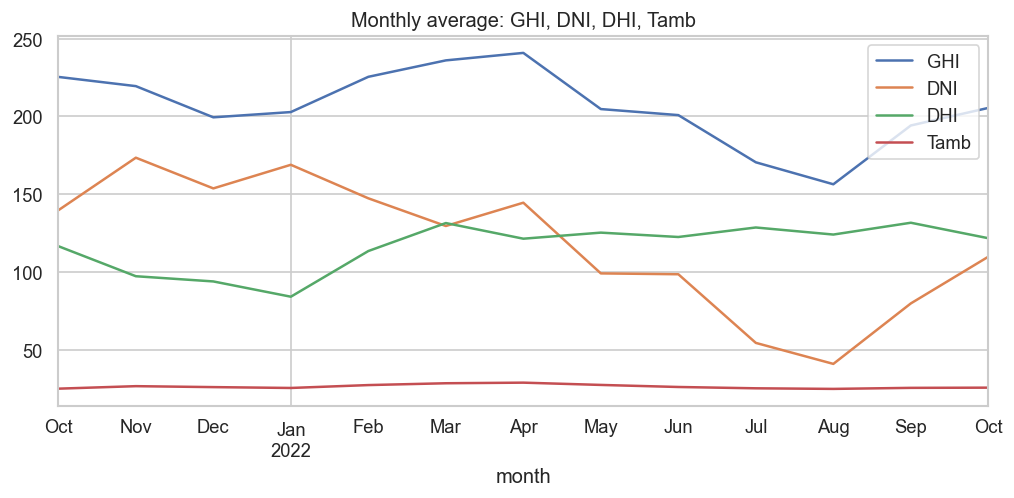

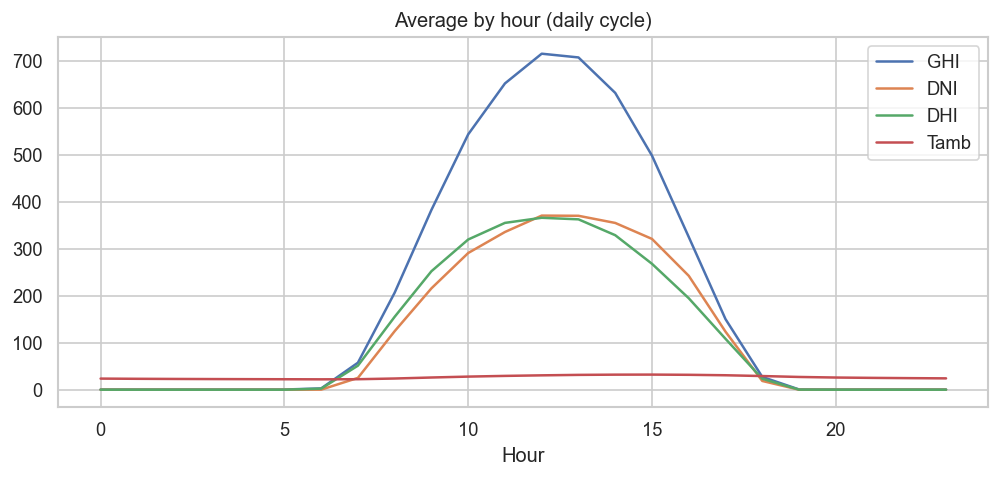

In [29]:
if not df.empty:
    if TIMESTAMP_COL in df.columns and not np.issubdtype(df[TIMESTAMP_COL].dtype, np.datetime64):
        df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL], errors='coerce')

    plot_cols = [c for c in ['GHI','DNI','DHI','Tamb'] if c in df.columns]
    if TIMESTAMP_COL not in df.columns:
        print(f"Timestamp column '{TIMESTAMP_COL}' not found — time series plots skipped")
    else:
        df_sorted = df.sort_values(TIMESTAMP_COL).reset_index(drop=True)
        plt.figure(figsize=(12,4))
        for c in plot_cols:
            plt.plot(df_sorted[TIMESTAMP_COL], df_sorted[c], label=c, alpha=0.8)
        plt.legend(); plt.title('Time series: ' + ', '.join(plot_cols)); plt.xlabel('Timestamp')
        plt.show()

        # monthly means
        df_sorted['month'] = df_sorted[TIMESTAMP_COL].dt.to_period('M')
        monthly = df_sorted.groupby('month')[plot_cols].mean()
        display(monthly.head())
        monthly.plot(kind='line', figsize=(10,4), title='Monthly average: ' + ', '.join(plot_cols))
        plt.show()

        # daily cycle by hour
        df_sorted['hour'] = df_sorted[TIMESTAMP_COL].dt.hour
        hourly = df_sorted.groupby('hour')[plot_cols].mean()
        hourly.plot(kind='line', figsize=(10,4), title='Average by hour (daily cycle)')
        plt.xlabel('Hour'); plt.show()

# 5 Cleaning Impact

,ModA,ModB
Cleaning,,
0,206.578599,198.038150
1,273.309252,277.231102


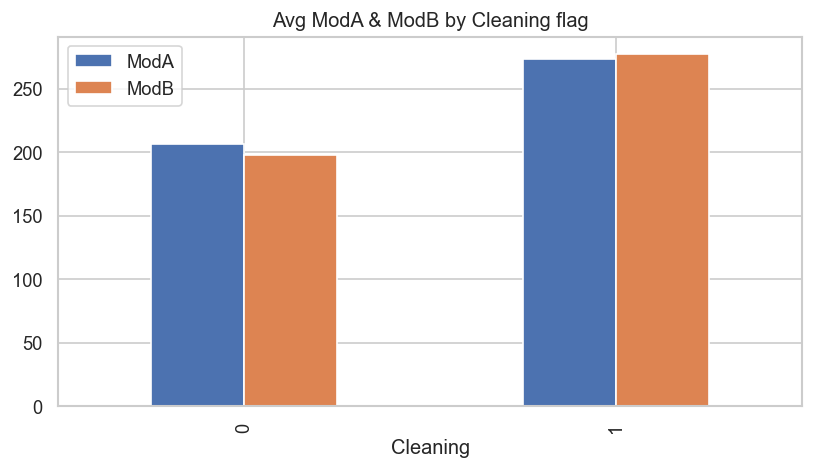

In [30]:
if not df.empty and CLEANING_FLAG_COL in df.columns and 'ModA' in df.columns and 'ModB' in df.columns:
    grp = df.groupby(CLEANING_FLAG_COL)[['ModA','ModB']].mean()
    display(grp)
    grp.plot(kind='bar', figsize=(8,4), title='Avg ModA & ModB by Cleaning flag')
    plt.show()
else:
    print(f"Cleaning flag '{CLEANING_FLAG_COL}' not present or ModA/ModB missing — skipped cleaning impact plots")


# 6 Correlation & Relationship Analysis
#### - Heatmap for selected columns
#### - Scatter plots for relationships

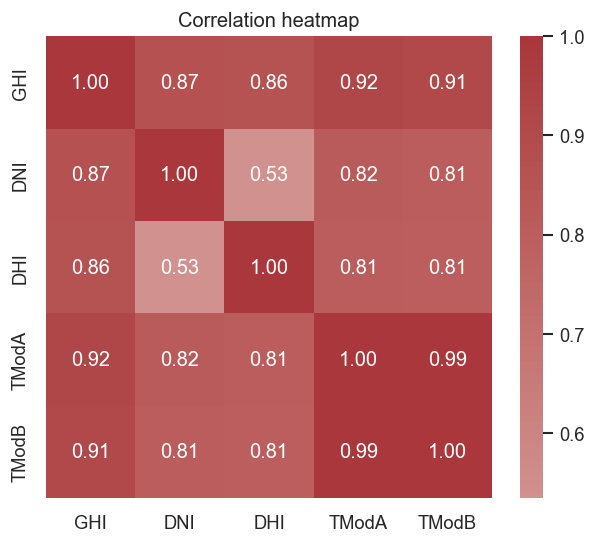

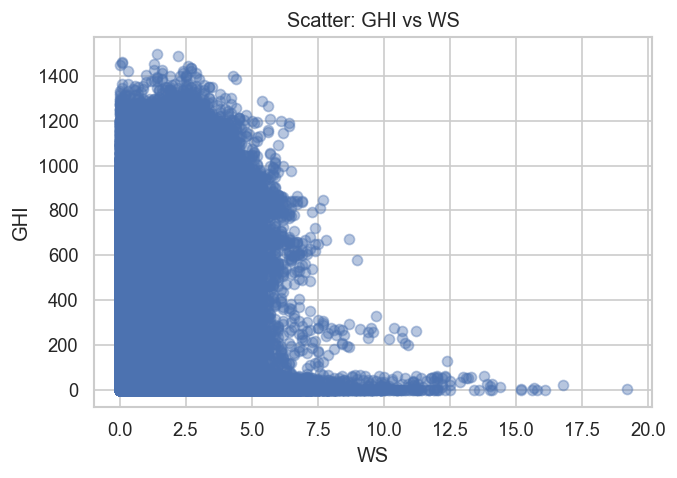

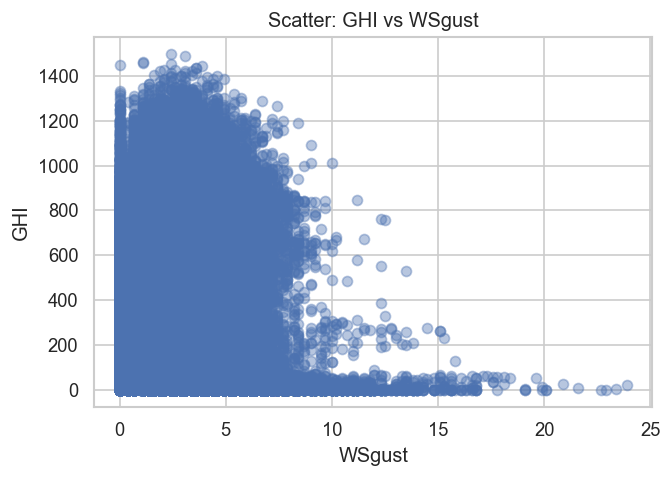

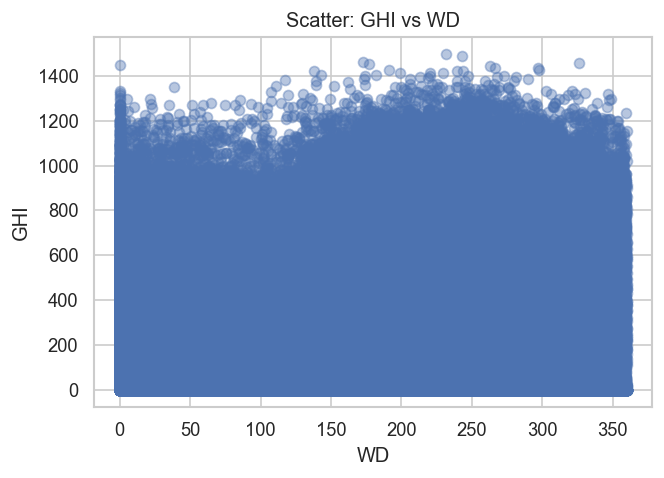

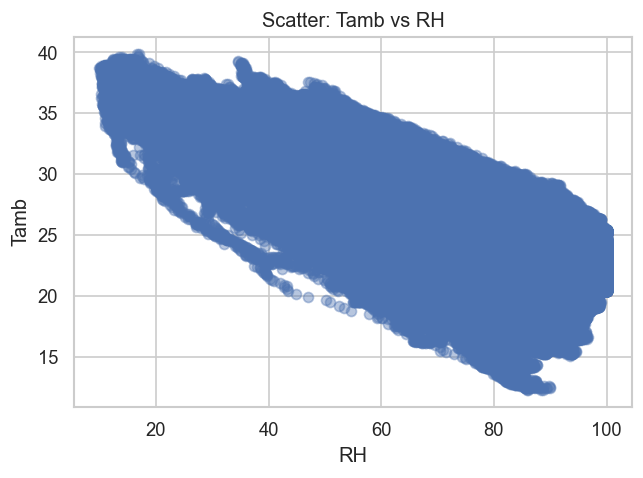

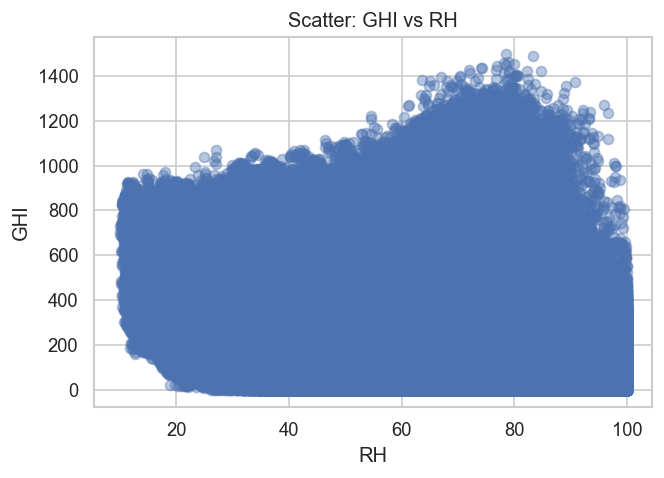

In [31]:
if not df.empty:
    corr_cols = [c for c in ['GHI','DNI','DHI','TModA','TModB'] if c in df.columns]
    if corr_cols:
        plt.figure(figsize=(6,5))
        sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='vlag', center=0)
        plt.title('Correlation heatmap')
        plt.show()

    scatter_pairs = [
        ('WS','GHI'), ('WSgust','GHI'), ('WD','GHI'),
        ('RH','Tamb'), ('RH','GHI')
    ]
    for x,y in scatter_pairs:
        if x in df.columns and y in df.columns:
            plt.figure(figsize=(6,4))
            plt.scatter(df[x], df[y], alpha=0.4)
            plt.xlabel(x); plt.ylabel(y)
            plt.title(f"Scatter: {y} vs {x}")
            plt.show()

# 7 Wind & Distribution Analysis
#### - Wind rose (radial bar plot) using WS and WD
#### - Histograms for GHI and WS

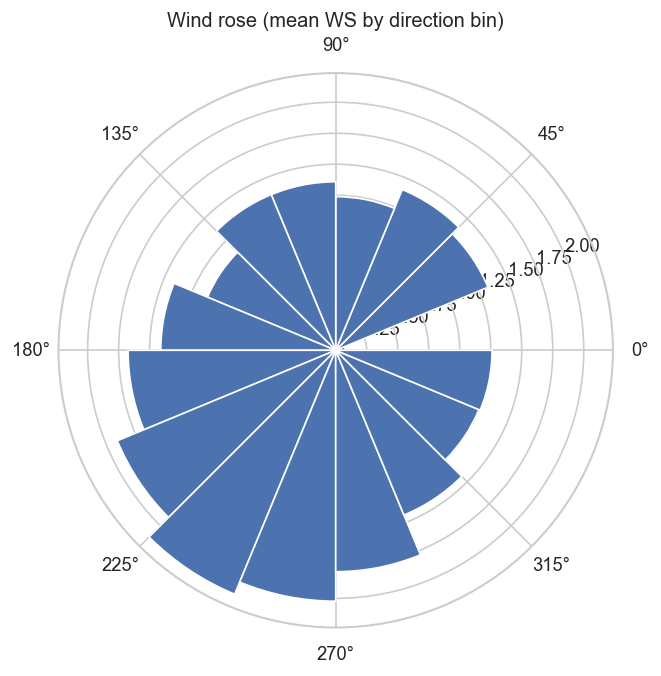

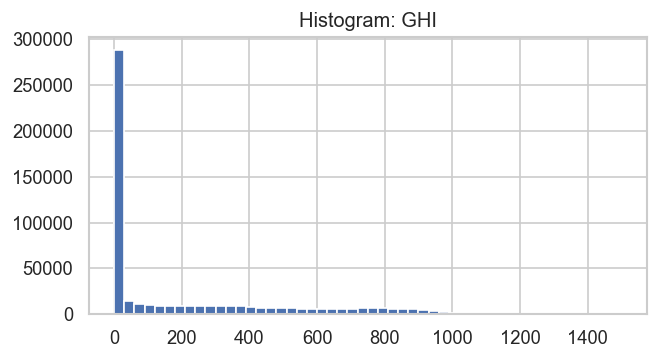

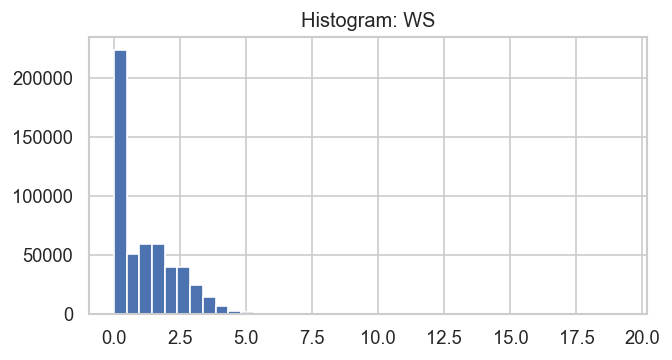

In [32]:
if not df.empty and 'WS' in df.columns and 'WD' in df.columns:
    wind = df[['WS','WD']].dropna().copy()
    wind['wd_mod'] = wind['WD'] % 360
    bins = np.linspace(0,360,17)
    wind['wd_bin'] = pd.cut(wind['wd_mod'], bins=bins, include_lowest=True, labels=False)
    rose = wind.groupby('wd_bin')['WS'].mean().reindex(range(16)).fillna(0)

    theta = np.linspace(0, 2*np.pi, len(rose), endpoint=False)
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, polar=True)
    bars = ax.bar(theta, rose.values, width=2*np.pi/len(rose), align='edge')
    ax.set_title('Wind rose (mean WS by direction bin)')
    plt.show()

    # histogram for GHI
    if 'GHI' in df.columns:
        plt.figure(figsize=(6,3))
        plt.hist(df['GHI'].dropna(), bins=50)
        plt.title('Histogram: GHI')
        plt.show()

    # histogram for WS
    plt.figure(figsize=(6,3))
    plt.hist(df['WS'].dropna(), bins=40)
    plt.title('Histogram: WS')
    plt.show()

# 8 Temperature & Humidity Analysis

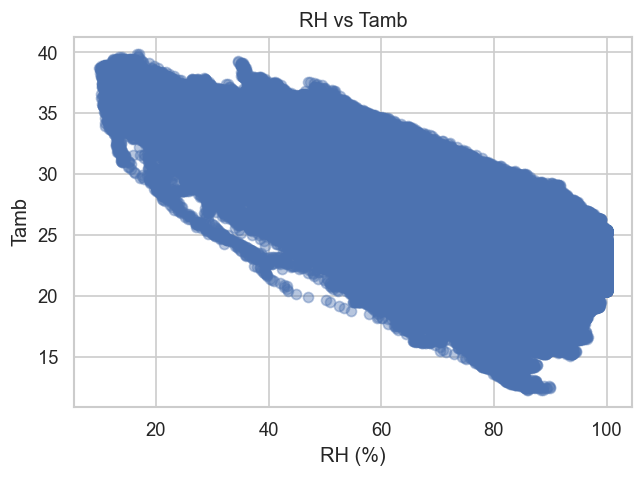

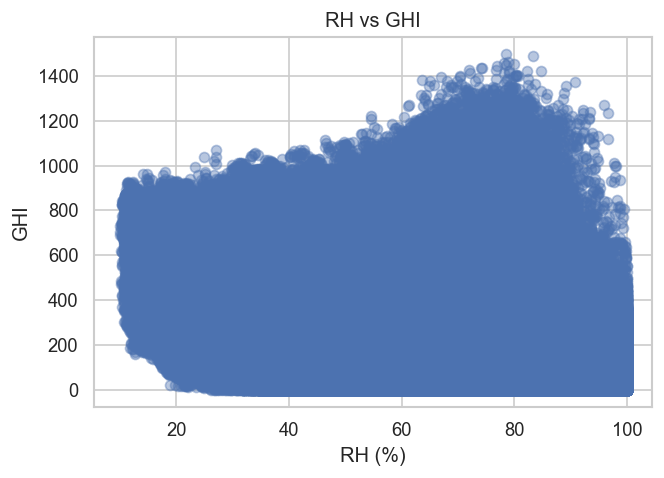

In [33]:
if not df.empty and 'RH' in df.columns and 'Tamb' in df.columns:
    plt.figure(figsize=(6,4))
    plt.scatter(df['RH'], df['Tamb'], alpha=0.4)
    plt.xlabel('RH (%)'); plt.ylabel('Tamb'); plt.title('RH vs Tamb'); plt.show()

    if 'GHI' in df.columns:
        plt.figure(figsize=(6,4))
        plt.scatter(df['RH'], df['GHI'], alpha=0.4)
        plt.xlabel('RH (%)'); plt.ylabel('GHI'); plt.title('RH vs GHI'); plt.show()

# 9 Bubble Chart: GHI vs Tamb (bubble size ~ RH)

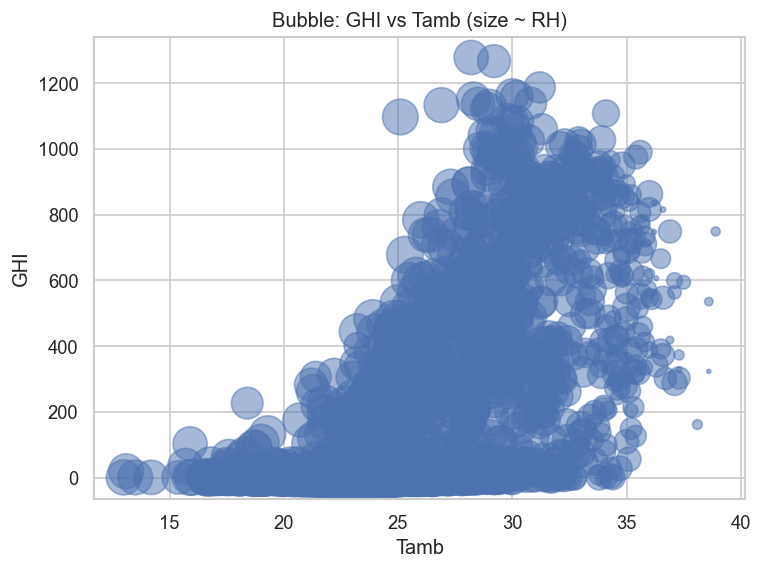

In [34]:
if not df.empty and 'GHI' in df.columns and 'Tamb' in df.columns and 'RH' in df.columns:
    sample = df.sample(n=min(2000, len(df)), random_state=42)
    sizes = (sample['RH'] - sample['RH'].min() + 1) * 6
    plt.figure(figsize=(7,5))
    plt.scatter(sample['Tamb'], sample['GHI'], s=sizes, alpha=0.5)
    plt.xlabel('Tamb'); plt.ylabel('GHI'); plt.title('Bubble: GHI vs Tamb (size ~ RH)')
    plt.show()

# 10 KPI & Findings (auto-generated text box)

In [35]:
if not df.empty:
    kpis = {}
    kpis['n_rows'] = len(df)
    kpis['n_cols'] = len(df.columns)
    kpis['n_missing_cols_gt5pct'] = len(cols_over_5pct) if 'cols_over_5pct' in locals() else 0
    kpis['n_outlier_rows'] = int(df['is_outlier_any'].sum()) if 'is_outlier_any' in df.columns else 0

    print("--- Quick KPIs ---")
    for k,v in kpis.items():
        print(f"{k}: {v}")

    print('Suggested actions:')
    print('- Investigate columns with >5% missing and decide if imputation or removal is appropriate.')
    print('- Review rows flagged as outliers (is_outlier_any). Consider whether they are sensor faults or rare-but-valid events.')
    print('- If Cleaning flag exists, use pre/post-clean grouping to quantify impact on module readings (ModA/ModB).')


--- Quick KPIs ---
n_rows: 525600
n_cols: 27
n_missing_cols_gt5pct: 1
n_outlier_rows: 16292
Suggested actions:
- Investigate columns with >5% missing and decide if imputation or removal is appropriate.
- Review rows flagged as outliers (is_outlier_any). Consider whether they are sensor faults or rare-but-valid events.
- If Cleaning flag exists, use pre/post-clean grouping to quantify impact on module readings (ModA/ModB).
